##Setup & Load Data


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import os, warnings
warnings.filterwarnings('ignore')

In [26]:
# Folder output
os.makedirs('/content/data/featured', exist_ok=True)
os.makedirs('/content/FE_figures',    exist_ok=True)

def save_fig(name):
    path = f'/content/FE_figures/{name}'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"✅ Tersimpan: {path}")

In [27]:
#Load dataset stunting (hasil data wrangling)
df = pd.read_csv('/content/dataset_stunting_clean.csv')

#Load data referensi WHO
who = pd.read_csv('/content/who_reference_master.csv')

# Konversi kolom numerik
kolom_num = ['usia_bulan','berat_badan','tinggi_badan',
             'zscore_bb_u','zscore_tb_u','zscore_bb_tb']
for col in kolom_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"✅ Dataset stunting : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"✅ WHO reference    : {who.shape[0]:,} baris x {who.shape[1]} kolom")
print(f"\n📌 Indikator WHO   : {who['indicator'].unique()}")
print(f"📌 Rentang usia WHO: {who['month'].min():.0f}–{who['month'].max():.0f} bulan")

✅ Dataset stunting : 40,066 baris x 11 kolom
✅ WHO reference    : 468 baris x 16 kolom

📌 Indikator WHO   : ['TB/U' 'BB/U' 'BB/TB']
📌 Rentang usia WHO: 0–60 bulan


##Merge dengan Referensi WHO (TB/U)

In [28]:
# Filter hanya indikator TB/U dari WHO
who_tbu = who[who['indicator'] == 'TB/U'][
    ['jenis_kelamin', 'month', 'l', 'm', 's',
     'sd3neg', 'sd2neg', 'sd1neg', 'sd0', 'sd1', 'sd2', 'sd3']
].copy()

who_tbu.columns = [
    'jenis_kelamin', 'usia_bulan',
    'who_l', 'who_m', 'who_s',
    'who_sd3neg', 'who_sd2neg', 'who_sd1neg',
    'who_median', 'who_sd1', 'who_sd2', 'who_sd3'
]

# Bulatkan usia ke integer agar bisa di-merge
df['usia_bulan_int'] = df['usia_bulan'].round(0).astype(int)
who_tbu['usia_bulan'] = who_tbu['usia_bulan'].astype(int)

# Merge berdasarkan jenis_kelamin + usia
df = df.merge(
    who_tbu,
    left_on=['jenis_kelamin', 'usia_bulan_int'],
    right_on=['jenis_kelamin', 'usia_bulan'],
    how='left',
    suffixes=('', '_who')
)
# Rapikan kolom duplikat
df.drop(columns=['usia_bulan_who'], errors='ignore', inplace=True)

print(f"✅ Merge selesai. Shape: {df.shape}")
print(f"\n📌 Contoh nilai WHO setelah merge:")
print(df[['id_anak','usia_bulan','jenis_kelamin',
          'tinggi_badan','who_median','who_sd2neg','who_sd3neg']].head(8))

✅ Merge selesai. Shape: (40893, 22)

📌 Contoh nilai WHO setelah merge:
   id_anak  usia_bulan jenis_kelamin  tinggi_badan  who_median  who_sd2neg  \
0        1        54.0     Perempuan          97.5       106.2        97.1   
1        2        44.0     Laki-laki          92.0       101.0        93.0   
2        3        57.0     Laki-laki          97.0       108.3        99.3   
3        4        26.0     Laki-laki          79.0        88.8        82.5   
4        5        59.0     Perempuan          98.0       108.9        99.5   
5        6        45.0     Perempuan          90.0       100.9        92.5   
6        7        58.0     Laki-laki          97.5       108.9        99.7   
7        8        50.0     Laki-laki          94.5       104.4        95.9   

   who_sd3neg  
0        92.6  
1        88.9  
2        94.7  
3        79.3  
4        94.7  
5        88.4  
6        95.2  
7        91.6  


##Hitung Z-Score WHO (Metode LMS)

In [29]:
# 3. HITUNG ULANG Z-SCORE BERDASARKAN LMS WHO
#    Formula: Z = ((X/M)^L - 1) / (L * S)
def hitung_zscore_who(row, col_ukur='tinggi_badan'):
    try:
        X = row[col_ukur]
        L = row['who_l']
        M = row['who_m']
        S = row['who_s']
        if pd.isna(X) or pd.isna(L) or pd.isna(M) or pd.isna(S):
            return np.nan
        if L == 0:
            return np.log(X / M) / S
        return ((X / M) ** L - 1) / (L * S)
    except:
        return np.nan

df['who_zscore_tbu'] = df.apply(hitung_zscore_who, axis=1)

# Validasi: bandingkan dengan zscore_tb_u dari dataset asli
corr = df[['who_zscore_tbu', 'zscore_tb_u']].dropna().corr()
print(f"✅ Korelasi z-score WHO vs dataset asli: {corr.iloc[0,1]:.4f}")
print(df[['usia_bulan','tinggi_badan','zscore_tb_u','who_zscore_tbu']].head(8))

✅ Korelasi z-score WHO vs dataset asli: 0.9808
   usia_bulan  tinggi_badan  zscore_tb_u  who_zscore_tbu
0        54.0          97.5        -2.11       -1.912523
1        44.0          92.0        -2.22       -2.235035
2        57.0          97.0        -2.58       -2.501880
3        26.0          79.0        -3.11       -3.087961
4        59.0          98.0        -2.49       -2.308465
5        45.0          90.0        -2.87       -2.608147
6        58.0          97.5        -2.49       -2.492302
7        50.0          94.5        -2.53       -2.330825


##Status WHO (Klasifikasi Berdasarkan Ambang Batas)

In [30]:
# 4. KLASIFIKASI STATUS WHO BERDASARKAN Z-SCORE TB/U
def status_who_tbu(z):
    if pd.isna(z):             return np.nan
    elif z < -3:               return 'Severely Stunted'
    elif z < -2:               return 'Stunting'
    elif z < -1:               return 'Risiko Stunting'
    elif z <= 2:               return 'Normal'
    else:                      return 'Tinggi'

df['who_status_tbu'] = df['who_zscore_tbu'].apply(status_who_tbu)

# Binary WHO: 1 = ada masalah stunting, 0 = normal/tinggi
df['who_flag_stunting'] = df['who_zscore_tbu'].apply(
    lambda z: 1 if (not pd.isna(z) and z < -2) else 0
)

print("📌 Distribusi Status WHO TB/U:")
print(df['who_status_tbu'].value_counts())
print(f"\n📌 Konsistensi WHO vs Dataset asli:")
cross = pd.crosstab(df['status_tb_u'], df['who_status_tbu'], margins=True)
print(cross)

📌 Distribusi Status WHO TB/U:
who_status_tbu
Risiko Stunting     14903
Normal              11041
Stunting            10481
Severely Stunted     4047
Tinggi                421
Name: count, dtype: int64

📌 Konsistensi WHO vs Dataset asli:
who_status_tbu  Normal  Risiko Stunting  Severely Stunted  Stunting  Tinggi  \
status_tb_u                                                                   
Stunting            66             2031              4045     10423       3   
Tidak Stunting   10975            12872                 2        58     418   
All              11041            14903              4047     10481     421   

who_status_tbu    All  
status_tb_u            
Stunting        16568  
Tidak Stunting  24325  
All             40893  


##Fitur Turunan dari WHO (Informatif untuk Model)

In [31]:
# Selisih tinggi badan aktual vs median WHO (positif = lebih tinggi dari median)
df['selisih_tb_who']       = df['tinggi_badan'] - df['who_median']

# Persentase tinggi badan terhadap median WHO
df['persen_median_who']    = (df['tinggi_badan'] / df['who_median']) * 100

# Jarak z-score dari batas stunting (-2 SD)
# Positif = masih di atas batas; Negatif = sudah melewati batas
df['jarak_ke_batas_sd2']   = df['who_zscore_tbu'] - (-2)

# Jarak tinggi badan aktual dari batas -2 SD WHO (cm)
df['selisih_tb_batas_sd2'] = df['tinggi_badan'] - df['who_sd2neg']

# Apakah tinggi badan di bawah -1 SD (zona waspada sebelum stunting)
df['flag_zona_waspada']    = (df['who_zscore_tbu'].between(-2, -1)).astype(int)

# Flag usia ≤ 24 bulan → eligible untuk prediksi AI
df['flag_eligible_ai']     = (df['usia_bulan'] <= 24).astype(int)

print("✅ Fitur turunan WHO berhasil dibuat:")
print(df[['usia_bulan','tinggi_badan','who_median',
          'selisih_tb_who','persen_median_who',
          'jarak_ke_batas_sd2','flag_zona_waspada',
          'flag_eligible_ai']].head(10))

✅ Fitur turunan WHO berhasil dibuat:
   usia_bulan  tinggi_badan  who_median  selisih_tb_who  persen_median_who  \
0        54.0          97.5       106.2            -8.7          91.807910   
1        44.0          92.0       101.0            -9.0          91.089109   
2        57.0          97.0       108.3           -11.3          89.566020   
3        26.0          79.0        88.8            -9.8          88.963964   
4        59.0          98.0       108.9           -10.9          89.990817   
5        45.0          90.0       100.9           -10.9          89.197225   
6        58.0          97.5       108.9           -11.4          89.531680   
7        50.0          94.5       104.4            -9.9          90.517241   
8        58.0          95.4       108.4           -13.0          88.007380   
9        57.0          81.0       108.3           -27.3          74.792244   

   jarak_ke_batas_sd2  flag_zona_waspada  flag_eligible_ai  
0            0.087477                  1   

##Fitur Umum (BMI, Rasio, Kelompok Usia)

In [32]:
# 6. FITUR UMUM (LANJUTAN DARI EDA)
# BMI
df['bmi'] = df['berat_badan'] / ((df['tinggi_badan'] / 100) ** 2)

# Rasio berat terhadap tinggi
df['rasio_bb_tb'] = df['berat_badan'] / df['tinggi_badan']

# Rata-rata semua z-score
df['zscore_mean'] = df[['zscore_bb_u','zscore_tb_u','zscore_bb_tb']].mean(axis=1)

# Kelompok usia
bins  = [0, 6, 12, 18, 24, 36, 48, 60]
label = ['0-6','6-12','12-18','18-24','24-36','36-48','48-60']
df['kelompok_usia'] = pd.cut(
    df['usia_bulan'], bins=bins, labels=label, right=True
)

# Flag risiko dari z-score
df['flag_gizi_buruk'] = (df['zscore_bb_u']  < -3).astype(int)
df['flag_kurus']      = (df['zscore_bb_tb'] < -2).astype(int)
df['flag_overweight'] = (df['bmi']          > 25).astype(int)

# Target binary stunting (dari dataset asli)
df['target_stunting'] = df['status_tb_u'].apply(
    lambda x: 1 if str(x).strip() == 'Stunting' else 0
)

print("✅ Fitur umum siap:")
print(df[['bmi','rasio_bb_tb','zscore_mean','kelompok_usia',
          'flag_gizi_buruk','flag_kurus','target_stunting']].head(8))

✅ Fitur umum siap:
         bmi  rasio_bb_tb  zscore_mean kelompok_usia  flag_gizi_buruk  \
0  13.885602     0.135385    -1.666667         48-60                0   
1  14.177694     0.130435    -1.673333         36-48                0   
2  14.879371     0.144330    -1.653333         48-60                0   
3  17.625381     0.139241    -1.193333         24-36                0   
4  15.201999     0.148980    -1.443333         48-60                0   
5  13.580247     0.122222    -2.350000         36-48                0   
6  14.727153     0.143590    -1.506667         48-60                0   
7  15.677053     0.148148    -1.243333         48-60                0   

   flag_kurus  target_stunting  
0           0                1  
1           0                1  
2           0                1  
3           0                1  
4           0                1  
5           0                1  
6           0                1  
7           0                1  


##Encoding Variabel Kategorik

In [33]:
le = LabelEncoder()

# Jenis kelamin → 0/1
df['jenis_kelamin_enc'] = le.fit_transform(df['jenis_kelamin'].fillna('Laki-laki'))
print("📌 Mapping gender:", dict(zip(le.classes_, le.transform(le.classes_))))

# Kelompok usia → ordinal
usia_map = {'0-6':1,'6-12':2,'12-18':3,'18-24':4,'24-36':5,'36-48':6,'48-60':7}
df['kelompok_usia_enc'] = df['kelompok_usia'].map(usia_map)

# WHO status TB/U → ordinal (makin tinggi angka = makin kritis)
who_status_map = {
    'Tinggi': 0, 'Normal': 1, 'Risiko Stunting': 2,
    'Stunting': 3, 'Severely Stunted': 4
}
df['who_status_enc'] = df['who_status_tbu'].map(who_status_map)

# One-Hot Encoding status_bb_u dan status_bb_tb
df = pd.get_dummies(
    df,
    columns=['status_bb_u', 'status_bb_tb'],
    prefix=['bb_u', 'bb_tb'],
    drop_first=False
)

print(f"\n✅ Shape setelah encoding: {df.shape}")

📌 Mapping gender: {'Laki-laki': np.int64(0), 'Perempuan': np.int64(1)}

✅ Shape setelah encoding: (40893, 48)


##Pisahkan Dataset AI (≤ 24 bln) & WHO-Only (> 24 bln)

In [34]:
# Dataset untuk training AI model (usia ≤ 24 bulan)
df_ai = df[df['usia_bulan'] <= 24].copy()

# Dataset hanya WHO (usia > 24 bulan — tidak dipakai AI)
df_who_only = df[df['usia_bulan'] > 24].copy()

print(f"📊 Dataset AI (≤ 24 bln)   : {len(df_ai):,} sampel")
print(f"📊 Dataset WHO-only (>24)  : {len(df_who_only):,} sampel")
print(f"\n📌 Distribusi target AI dataset:")
print(df_ai['target_stunting'].value_counts())
print(f"\n📌 Distribusi target WHO-only:")
print(df_who_only['target_stunting'].value_counts())

📊 Dataset AI (≤ 24 bln)   : 14,004 sampel
📊 Dataset WHO-only (>24)  : 26,889 sampel

📌 Distribusi target AI dataset:
target_stunting
0    8235
1    5769
Name: count, dtype: int64

📌 Distribusi target WHO-only:
target_stunting
0    16090
1    10799
Name: count, dtype: int64


##Handle Missing Values & Scaling

In [35]:
# Fitur final untuk model AI
fitur_ai = [
    # Numerik asli
    'usia_bulan', 'berat_badan', 'tinggi_badan',
    'zscore_bb_u', 'zscore_tb_u', 'zscore_bb_tb',
    # Fitur WHO
    'who_zscore_tbu', 'who_median', 'selisih_tb_who',
    'persen_median_who', 'jarak_ke_batas_sd2', 'selisih_tb_batas_sd2',
    # Fitur turunan
    'bmi', 'rasio_bb_tb', 'zscore_mean',
    # Encoding
    'jenis_kelamin_enc', 'kelompok_usia_enc', 'who_status_enc',
    # Flag
    'flag_zona_waspada', 'flag_gizi_buruk', 'flag_kurus',
] + [c for c in df_ai.columns if c.startswith(('bb_u_', 'bb_tb_'))]

# Filter kolom yang ada
fitur_ai = [c for c in fitur_ai if c in df_ai.columns]

X = df_ai[fitur_ai].copy()
y = df_ai['target_stunting'].copy()

# Imputasi median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

print(f"✅ Fitur AI     : {len(fitur_ai)} fitur")
print(f"✅ Sampel AI    : {len(X_scaled):,}")
print(f"✅ Missing setelah imputasi: {X_imputed.isnull().sum().sum()}")
print(f"\n📌 Daftar fitur AI:")
for i, f in enumerate(fitur_ai, 1):
    print(f"  {i:2d}. {f}")

✅ Fitur AI     : 29 fitur
✅ Sampel AI    : 14,004
✅ Missing setelah imputasi: 0

📌 Daftar fitur AI:
   1. usia_bulan
   2. berat_badan
   3. tinggi_badan
   4. zscore_bb_u
   5. zscore_tb_u
   6. zscore_bb_tb
   7. who_zscore_tbu
   8. who_median
   9. selisih_tb_who
  10. persen_median_who
  11. jarak_ke_batas_sd2
  12. selisih_tb_batas_sd2
  13. bmi
  14. rasio_bb_tb
  15. zscore_mean
  16. jenis_kelamin_enc
  17. kelompok_usia_enc
  18. who_status_enc
  19. flag_zona_waspada
  20. flag_gizi_buruk
  21. flag_kurus
  22. bb_u_Gizi Buruk
  23. bb_u_Gizi Kurang
  24. bb_u_Gizi Lebih
  25. bb_u_Normal
  26. bb_tb_Kurus
  27. bb_tb_Normal
  28. bb_tb_Obesitas
  29. bb_tb_Sangat Kurus


##Visualisasi Fitur Kunci

✅ Tersimpan: /content/FE_figures/feature_engineering_who.png


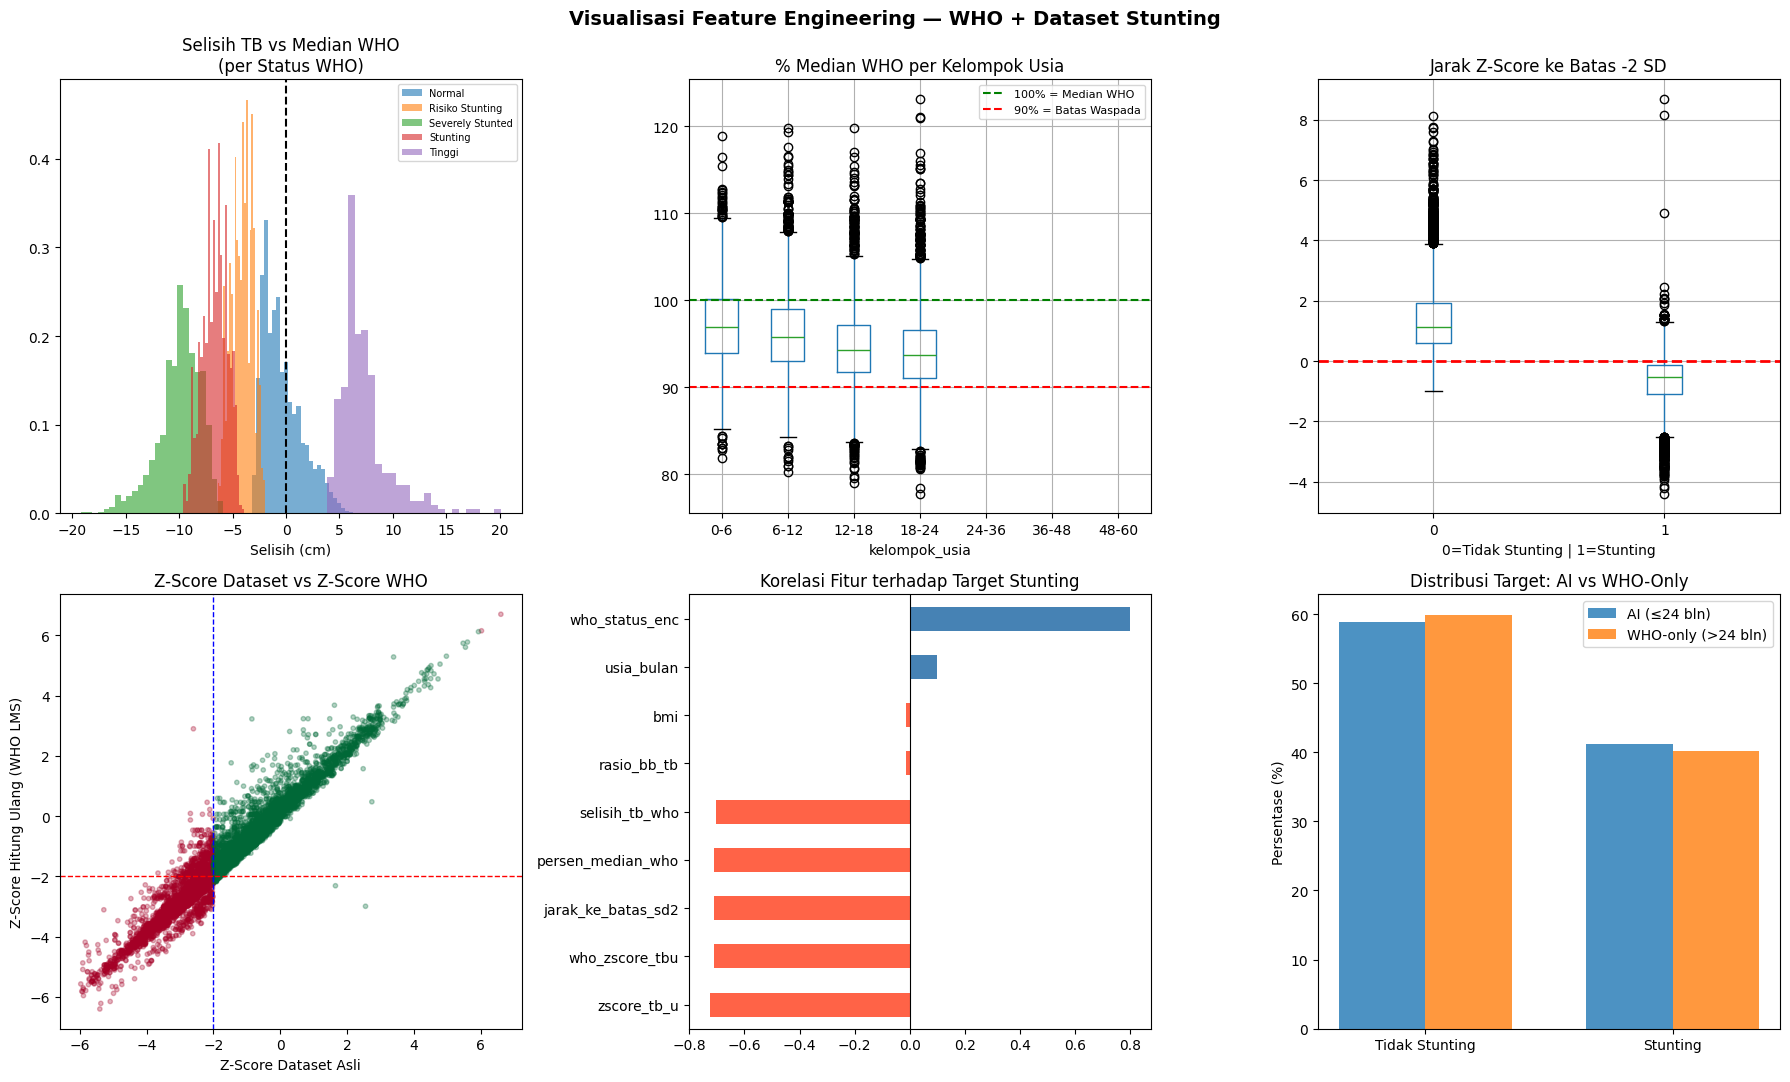

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Selisih TB vs Median WHO per status
for status, grp in df_ai.groupby('who_status_tbu'):
    axes[0,0].hist(grp['selisih_tb_who'].dropna(), bins=25,
                   alpha=0.6, label=status, density=True)
axes[0,0].axvline(0, color='black', lw=1.5, ls='--')
axes[0,0].set_title('Selisih TB vs Median WHO\n(per Status WHO)')
axes[0,0].set_xlabel('Selisih (cm)')
axes[0,0].legend(fontsize=7)

# 2. Persen Median WHO per kelompok usia (AI only)
df_ai.boxplot(column='persen_median_who', by='kelompok_usia', ax=axes[0,1])
axes[0,1].axhline(100, color='green', ls='--', label='100% = Median WHO')
axes[0,1].axhline(90,  color='red',   ls='--', label='90% = Batas Waspada')
axes[0,1].set_title('% Median WHO per Kelompok Usia (≤24 bln)')
axes[0,1].legend(fontsize=8)
plt.sca(axes[0,1]); plt.title('% Median WHO per Kelompok Usia')

# 3. Jarak ke batas SD-2 per target
df_ai.boxplot(column='jarak_ke_batas_sd2', by='target_stunting', ax=axes[0,2])
axes[0,2].axhline(0, color='red', ls='--', lw=2, label='Batas Stunting')
axes[0,2].set_title('Jarak Z-Score ke Batas -2 SD')
axes[0,2].set_xlabel('0=Tidak Stunting | 1=Stunting')
plt.sca(axes[0,2]); plt.title('Jarak Z-Score ke Batas -2 SD')

# 4. WHO Z-Score vs Z-Score Dataset
axes[1,0].scatter(df_ai['zscore_tb_u'], df_ai['who_zscore_tbu'],
                  alpha=0.3, s=10, c=df_ai['target_stunting'],
                  cmap='RdYlGn_r')
axes[1,0].axhline(-2, color='red', ls='--', lw=1)
axes[1,0].axvline(-2, color='blue', ls='--', lw=1)
axes[1,0].set_title('Z-Score Dataset vs Z-Score WHO')
axes[1,0].set_xlabel('Z-Score Dataset Asli')
axes[1,0].set_ylabel('Z-Score Hitung Ulang (WHO LMS)')

# 5. Korelasi fitur dengan target
fitur_corr_plot = ['who_zscore_tbu','zscore_tb_u','selisih_tb_who',
                   'persen_median_who','jarak_ke_batas_sd2','bmi',
                   'rasio_bb_tb','usia_bulan','who_status_enc']
corr_vals = df_ai[fitur_corr_plot + ['target_stunting']].corr()['target_stunting'].drop('target_stunting').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_vals]
corr_vals.plot(kind='barh', ax=axes[1,1], color=colors)
axes[1,1].axvline(0, color='black', lw=0.8)
axes[1,1].set_title('Korelasi Fitur terhadap Target Stunting')

# 6. Distribusi target AI vs WHO-only
ax = axes[1,2]
data_plot = {
    'AI (≤24 bln)': df_ai['target_stunting'].value_counts(normalize=True)*100,
    'WHO-only (>24 bln)': df_who_only['target_stunting'].value_counts(normalize=True)*100
}
x = np.arange(2)
width = 0.35
for i, (label_key, vals) in enumerate(data_plot.items()):
    ax.bar(x + i*width, [vals.get(0,0), vals.get(1,0)], width,
           label=label_key, alpha=0.8)
ax.set_xticks(x + width/2)
ax.set_xticklabels(['Tidak Stunting','Stunting'])
ax.set_title('Distribusi Target: AI vs WHO-Only')
ax.set_ylabel('Persentase (%)')
ax.legend()

plt.suptitle('Visualisasi Feature Engineering — WHO + Dataset Stunting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('feature_engineering_who.png')
plt.show()

##Simpan Semua Dataset

In [37]:
base = '/content/data/featured'

#Dataset AI (≤ 24 bulan)
df_ai_save = X_imputed.copy()
df_ai_save['target_stunting'] = y.values

df_ai_save.to_csv(f'{base}/dataset_ai_usia_0_24.csv', index=False)
print(f"✅ Dataset AI tersimpan     : {base}/dataset_ai_usia_0_24.csv")
print(f"   Shape: {df_ai_save.shape}")

#Dataset AI versi scaled
df_ai_scaled = X_scaled.copy()
df_ai_scaled['target_stunting'] = y.values
df_ai_scaled.to_csv(f'{base}/dataset_ai_scaled.csv', index=False)
print(f"✅ Dataset AI scaled        : {base}/dataset_ai_scaled.csv")

#Dataset WHO-only (> 24 bulan)
kolom_who_only = ['id_anak','jenis_kelamin','usia_bulan','berat_badan',
                  'tinggi_badan','who_zscore_tbu','who_status_tbu',
                  'who_flag_stunting','selisih_tb_who',
                  'persen_median_who','jarak_ke_batas_sd2',
                  'who_median','who_sd2neg','who_sd3neg',
                  'target_stunting']
kolom_who_only = [c for c in kolom_who_only if c in df_who_only.columns]
df_who_only[kolom_who_only].to_csv(f'{base}/dataset_who_only_usia_25_60.csv', index=False)
print(f"✅ Dataset WHO-only tersimpan: {base}/dataset_who_only_usia_25_60.csv")

#Dataset master lengkap
df.to_csv(f'{base}/dataset_master_featured.csv', index=False)
print(f"✅ Dataset master tersimpan : {base}/dataset_master_featured.csv")

✅ Dataset AI tersimpan     : /content/data/featured/dataset_ai_usia_0_24.csv
   Shape: (14004, 30)
✅ Dataset AI scaled        : /content/data/featured/dataset_ai_scaled.csv
✅ Dataset WHO-only tersimpan: /content/data/featured/dataset_who_only_usia_25_60.csv
✅ Dataset master tersimpan : /content/data/featured/dataset_master_featured.csv


##Ringkasan

In [38]:
print("\n" + "=" * 65)
print("RINGKASAN FEATURE ENGINEERING")
print("=" * 65)
print(f"""
📦 SUMBER DATA:
   ├─ dataset_stunting_clean.csv  → {len(df):,} sampel (0–60 bln)
   └─ who_reference_master.csv   → standar z-score TB/U, BB/U, BB/TB

🆕 FITUR WHO BARU (6):
   ├─ who_zscore_tbu       → z-score TB/U dihitung ulang via LMS
   ├─ who_status_tbu       → Normal/Risiko/Stunting/Severely Stunted
   ├─ selisih_tb_who       → tinggi_badan - median WHO (cm)
   ├─ persen_median_who    → (tinggi_badan / median WHO) × 100
   ├─ jarak_ke_batas_sd2   → zscore_who - (-2) → margin ke batas stunting
   └─ selisih_tb_batas_sd2 → tinggi_badan - batas -2SD WHO (cm)

📊 FITUR TURUNAN UMUM (5):
   bmi, rasio_bb_tb, zscore_mean, flag_zona_waspada, kelompok_usia

🎯 TARGET: target_stunting (0 = Tidak Stunting | 1 = Stunting)

🗂️ OUTPUT FILES:
   ├─ dataset_ai_usia_0_24.csv       → {len(df_ai):,} sampel → TRAINING AI
   ├─ dataset_ai_scaled.csv          → versi StandardScaler
   ├─ dataset_who_only_usia_25_60.csv → {len(df_who_only):,} sampel → referensi WHO saja
   └─ dataset_master_featured.csv    → semua data lengkap

🤖 LOGIKA WEB APP:
   ├─ Usia ≤ 24 bln → WHO + Prediksi AI (probabilitas stunting)
   │    • WHO Normal + AI > 70% → pesan peringatan khusus
   │    • WHO Normal + AI ≤ 70% → pesan aman
   │    • WHO Stunting + AI apapun → pesan intervensi segera
   └─ Usia > 24 bln → Hasil WHO saja + catatan "AI tidak tersedia"
""")
print(f"✅ Total fitur untuk model AI : {len(fitur_ai)}")
print(f"✅ Sampel training AI          : {len(df_ai):,}")
print(f"✅ Sampel WHO-only             : {len(df_who_only):,}")


RINGKASAN FEATURE ENGINEERING

📦 SUMBER DATA:
   ├─ dataset_stunting_clean.csv  → 40,893 sampel (0–60 bln)
   └─ who_reference_master.csv   → standar z-score TB/U, BB/U, BB/TB

🆕 FITUR WHO BARU (6):
   ├─ who_zscore_tbu       → z-score TB/U dihitung ulang via LMS
   ├─ who_status_tbu       → Normal/Risiko/Stunting/Severely Stunted
   ├─ selisih_tb_who       → tinggi_badan - median WHO (cm)
   ├─ persen_median_who    → (tinggi_badan / median WHO) × 100
   ├─ jarak_ke_batas_sd2   → zscore_who - (-2) → margin ke batas stunting
   └─ selisih_tb_batas_sd2 → tinggi_badan - batas -2SD WHO (cm)

📊 FITUR TURUNAN UMUM (5):
   bmi, rasio_bb_tb, zscore_mean, flag_zona_waspada, kelompok_usia

🎯 TARGET: target_stunting (0 = Tidak Stunting | 1 = Stunting)

🗂️ OUTPUT FILES:
   ├─ dataset_ai_usia_0_24.csv       → 14,004 sampel → TRAINING AI
   ├─ dataset_ai_scaled.csv          → versi StandardScaler
   ├─ dataset_who_only_usia_25_60.csv → 26,889 sampel → referensi WHO saja
   └─ dataset_master_feature